In [4]:
import numpy as np

In [2]:
multipliers = np.array([(55**6 * 25), (55**5 * 25), (55**4 * 25), (55**3 * 25), (55**2 * 25), (55**1 * 25), 25, 5, 1])
element_weights = np.array(
    [
        64, 27, 27, 27, 27, 27, 27, 4, 4,
        16,  9,  9,  9,  9,  9,  9, 3, 3,
         4,  3,  3,  3,  3,  3,  3, 2, 2,
         1,  1,  1,  1,  1,  1,  1, 1, 1
    ]
)
hash_weights = element_weights * np.tile(multipliers, 4)

In [3]:
S = np.array(
    [
        1, 0, 0, 0, 0, 2, 0, 0, 0,
        0, 0, 1, 1, 0, 0, 0, 1, 0,
        2, 2, 0, 0, 0, 0, 0, 0, 1,
        0, 0, 0, 1, 1, 0, 0, 0, 0
    ]
)

In [4]:
S_hash = np.dot(S, hash_weights)

In [5]:
S_hash

np.int64(49902746415517)

In [6]:
S_recovered = np.empty(9 * 4, dtype=int)
current_S_hash = S_hash

for c in range(9):
    col = current_S_hash // multipliers[c]
    for r in range(4):
        v = col // element_weights[(r * 9) + c]
        S_recovered[(r * 9) + c] = int(v)
        col = col % element_weights[(r * 9) + c]
    current_S_hash = current_S_hash % multipliers[c]

In [7]:
S_recovered

array([1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 2, 2, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0])

In [8]:
S

array([1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 2, 2, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0])

In [9]:
# Max possible state

In [10]:
S = np.array(
    [
        3, 2, 2, 2, 2, 2, 2, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0
    ]
)

In [11]:
S_hash = np.dot(S, hash_weights)

In [12]:
S_hash

np.int64(133559091015624)

decomposition analysis

In [5]:
import ciw
import matplotlib.pyplot as plt

In [6]:
arrival_rate = 10

In [14]:
def get_effective_arrival_rates(arrival_rate, service_rate):
    N = ciw.create_network(
        arrival_distributions=[ciw.dists.Exponential(rate=arrival_rate),
                               None,
                               None],
        service_distributions=[ciw.dists.Deterministic(value=0),
                               ciw.dists.Exponential(rate=service_rate),
                               ciw.dists.Exponential(rate=service_rate)],
        number_of_servers=[float('inf'),
                           17,
                           17],
        routing=ciw.routing.NetworkRouting(
            routers=[
                ciw.routing.LoadBalancing(destinations=[2, 3]),
                ciw.routing.Leave(),
                ciw.routing.Leave()
            ]
        )
    )
    Q = ciw.Simulation(N, tracker=ciw.trackers.NodePopulationSubset([1, 2]))
    Q.simulate_until_max_time(30000, progress_bar=True)
    probs = Q.statetracker.state_probabilities(observation_period=(500, 29900))

    prob_less_than = {i: 0.0 for i in range(18)}
    prob_equal = {i: 0.0 for i in range(18)}
    prob_total = {i: 0.0 for i in range(18)}
    for n1 in range(18):
        for n2 in range(18):
            p = probs.get((n1, n2), 0.0)
            prob_total[n1] += p
            if n1 < n2:
                prob_less_than[n1] += p
            if n1 == n2:
                prob_equal[n1] += p

    for n in range(18):
        if prob_total[n] != 0:
            prob_less_than[n] /= prob_total[n]
            prob_equal[n] /= prob_total[n]

    effective_arrival_rates = [(prob_less_than[n] * arrival_rate) + (prob_equal[n] * arrival_rate / 2) for n in range(18)]
    return effective_arrival_rates

In [15]:
effective_arrival_rates_08 = get_effective_arrival_rates(8, 0.5)
effective_arrival_rates_10 = get_effective_arrival_rates(10, 0.5)
effective_arrival_rates_12 = get_effective_arrival_rates(12, 0.5)
effective_arrival_rates_14 = get_effective_arrival_rates(14, 0.5)

100%|███████████████████████████████| 30000.0/30000 [00:22<00:00, 1345.50it/s]
100%|███████████████████████████████| 30000.0/30000 [00:28<00:00, 1069.12it/s]
100%|████████████████████████████████| 30000.0/30000 [00:36<00:00, 811.32it/s]
100%|████████████████████████████████| 30000.0/30000 [00:42<00:00, 713.77it/s]


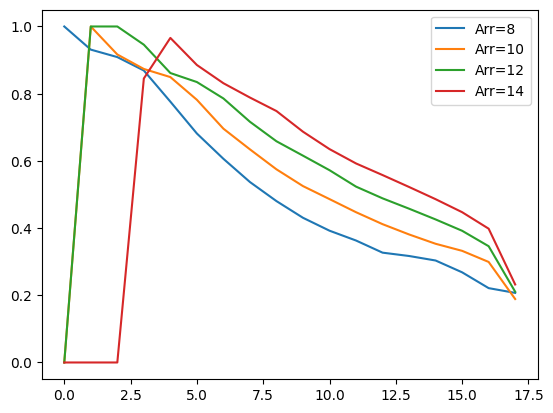

In [17]:
fig, ax = plt.subplots(1)
ax.plot(range(18), [p / 8 for p in effective_arrival_rates_08], label="Arr=8")
ax.plot(range(18), [p / 10 for p in effective_arrival_rates_10], label="Arr=10")
ax.plot(range(18), [p / 12 for p in effective_arrival_rates_12], label="Arr=12")
ax.plot(range(18), [p / 14 for p in effective_arrival_rates_14], label="Arr=14")
plt.legend()
plt.show()

In [3]:
import numpy as np
hits = np.load("../stage_1_overall_hits_epsilon0.0.npy", mmap_mode='r')

In [9]:
from collections import Counter

In [16]:
94999026 / len(hits)

0.868439143535073

In [14]:
C = Counter(hits)

In [15]:
C

Counter({np.int16(1): 94999026,
         np.int16(2): 8511269,
         np.int16(3): 2509296,
         np.int16(4): 1123876,
         np.int16(5): 616251,
         np.int16(6): 379971,
         np.int16(7): 253444,
         np.int16(8): 180301,
         np.int16(9): 132514,
         np.int16(10): 101041,
         np.int16(11): 78395,
         np.int16(12): 62485,
         np.int16(13): 50888,
         np.int16(14): 41994,
         np.int16(15): 35322,
         np.int16(16): 29930,
         np.int16(17): 25800,
         np.int16(18): 22464,
         np.int16(19): 19752,
         np.int16(20): 17027,
         np.int16(21): 15105,
         np.int16(22): 13356,
         np.int16(23): 11657,
         np.int16(24): 10449,
         np.int16(25): 9300,
         np.int16(26): 8362,
         np.int16(27): 7587,
         np.int16(28): 6835,
         np.int16(29): 6207,
         np.int16(30): 5786,
         np.int16(31): 5404,
         np.int16(32): 4838,
         np.int16(33): 4529,
         np.i